# Workbook 7 — Multi-Year Trend & Seasonality Analysis

## 1.0 Helper Function — Column Standardization

- Ensure column formatting consistency across all years.
- Remove leading/trailing whitespace.
- Prevent silent column mismatch during concatenation.

In [2]:
def standardize_columns(df):
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )
    return df

## 1.1 Inspect Raw 2023 Sales Report Structure (Robust Read)

- Use python engine to tolerate irregular rows.
- Explicitly define comma delimiter.
- Disable strict error throwing.
- Inspect first 20 rows to locate true header row.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
sales_2023_preview = pd.read_csv(
    "../data/raw/sales_reports_2023.csv",
    sep="\t",
    engine="python",
    header=None,
    on_bad_lines="skip"
)

sales_2023_preview.head(20)

,0
0,Sales Report
1,"Sun, Jan 1, 2023, 12:00 AM - Sun, Dec 31, 202..."
2,"Requested on: Mon, Jan 12, 2026, 6:09 PM"
3,Filters: none
4,"Net sales,""$761,713.58"",""from 26,385 orders"""
5,"Amount Collected,""$838,651.69"""
6,"Gross sales,""$765,542.33"""
7,"Unpaid Balance,$573.77,from 46 partial orders"
8,Sales
9,",Total,January,February,March,April,May,June,J..."


## 1.2 Identify Monthly Table Header Row

- The preview confirms Clover report metadata precedes the real table.
- The monthly table header begins on the row containing:
  - `,Total,January,February,...,December`
- Use that row index as the fixed `skiprows` value for a clean monthly table load.
- This is Journal-approved: explicit, transparent, reproducible.

In [5]:
# From your preview, the monthly header row is index 9
skiprows_2023 = 9

## 1.3 Load Monthly Table (2023)

- Load the monthly section starting at the header row.
- Use `engine="python"` + `on_bad_lines="skip"` to tolerate Clover formatting.
- Validate that columns include `Total` and all months.

In [6]:
sales_monthly_2023 = pd.read_csv(
    "../data/raw/sales_reports_2023.csv",
    skiprows=skiprows_2023,
    engine="python",
    on_bad_lines="skip"
)

sales_monthly_2023 = standardize_columns(sales_monthly_2023)

sales_monthly_2023.head(12)

,,,,,,,,,,,,,Sales
NaN,Total,January,February,March,April,May,June,July,August,September,October,November,December
Gross sales,"$765,542.33",$12.77,$77.51,$22.99,"$62,756.22","$87,652.99","$91,902.91","$91,086.63","$84,236.34","$87,399.62","$90,131.93","$80,394.00","$89,868.42"
Discounts,"-$2,388.93",$0.00,$0.00,$0.00,-$25.62,-$155.34,-$131.10,-$382.36,-$353.14,-$334.97,-$402.31,-$307.32,-$296.77
Repayments,$372.75,$0.00,$0.00,$0.00,$91.92,$86.49,$72.39,$81.03,$0.00,$28.97,$11.95,$0.00,$0.00
Refunds,"-$1,812.57",-$12.77,$0.00,$0.00,-$372.08,-$243.92,-$289.35,-$111.31,-$60.02,-$93.93,-$405.88,-$105.14,-$118.17
Net sales,"$761,713.58",$0.00,$77.51,$22.99,"$62,450.44","$87,340.22","$91,554.85","$90,673.99","$83,823.18","$86,999.69","$89,335.69","$79,981.54","$89,453.48"
Overpayments,$32.55,$0.00,$0.00,$0.00,$0.00,$0.00,$0.00,$0.00,$32.55,$0.00,$0.00,$0.00,$0.00
Taxes expected,"$66,534.15",$0.00,$6.78,$2.01,"$5,463.38","$7,642.08","$8,006.23","$7,926.00","$7,334.08","$7,606.71","$7,809.18","$6,963.60","$7,796.02"
Taxes collected,"$66,520.36",$0.00,$6.78,$2.01,"$5,460.69","$7,631.90","$8,004.26","$7,930.19","$7,329.65","$7,597.26","$7,803.58","$6,962.74","$7,791.30"
Tips,"$10,903.15",$0.00,$0.00,$0.00,$714.09,"$1,322.23","$1,245.83","$1,286.00","$1,299.85","$1,441.97","$1,256.57","$1,020.98","$1,315.63"


## 1.4 Validate Monthly Table Structure (2023)

- Confirm first column contains metric labels.
- Confirm month columns exist (January–December).
- Ensure no structural corruption from skiprows.

In [7]:
sales_monthly_2023.columns

Index(['Sales'], dtype='object')

## 1.4a Fix Header Misread (2023)

- Your `sales_monthly_2023.columns` returning `Index(['Sales'], dtype='object')` means pandas used the **"Sales"** line as the header.
- That happens when `skiprows` starts on the line containing `Sales` (row 8), not the true monthly header row (row 9).
- Fix: set `skiprows_2023 = 9` and re-load.

In [8]:
# Clover monthly header row (0-based) is the line: ,Total,January,...,December
skiprows_2023 = 11

sales_monthly_2023 = pd.read_csv(
    "../data/raw/sales_reports_2023.csv",
    skiprows=skiprows_2023,
    sep=",",
    engine="python",
    on_bad_lines="skip"
)

sales_monthly_2023 = standardize_columns(sales_monthly_2023)

sales_monthly_2023.head(12)

,Unnamed: 0,Total,January,February,March,April,May,June,July,August,September,October,November,December
0,Gross sales,"$765,542.33",$12.77,$77.51,$22.99,"$62,756.22","$87,652.99","$91,902.91","$91,086.63","$84,236.34","$87,399.62","$90,131.93","$80,394.00","$89,868.42"
1,Discounts,"-$2,388.93",$0.00,$0.00,$0.00,-$25.62,-$155.34,-$131.10,-$382.36,-$353.14,-$334.97,-$402.31,-$307.32,-$296.77
2,Repayments,$372.75,$0.00,$0.00,$0.00,$91.92,$86.49,$72.39,$81.03,$0.00,$28.97,$11.95,$0.00,$0.00
3,Refunds,"-$1,812.57",-$12.77,$0.00,$0.00,-$372.08,-$243.92,-$289.35,-$111.31,-$60.02,-$93.93,-$405.88,-$105.14,-$118.17
4,Net sales,"$761,713.58",$0.00,$77.51,$22.99,"$62,450.44","$87,340.22","$91,554.85","$90,673.99","$83,823.18","$86,999.69","$89,335.69","$79,981.54","$89,453.48"
5,Overpayments,$32.55,$0.00,$0.00,$0.00,$0.00,$0.00,$0.00,$0.00,$32.55,$0.00,$0.00,$0.00,$0.00
6,Taxes expected,"$66,534.15",$0.00,$6.78,$2.01,"$5,463.38","$7,642.08","$8,006.23","$7,926.00","$7,334.08","$7,606.71","$7,809.18","$6,963.60","$7,796.02"
7,Taxes collected,"$66,520.36",$0.00,$6.78,$2.01,"$5,460.69","$7,631.90","$8,004.26","$7,930.19","$7,329.65","$7,597.26","$7,803.58","$6,962.74","$7,791.30"
8,Tips,"$10,903.15",$0.00,$0.00,$0.00,$714.09,"$1,322.23","$1,245.83","$1,286.00","$1,299.85","$1,441.97","$1,256.57","$1,020.98","$1,315.63"
9,transactions fee,$2.13,$0.00,$0.00,$0.00,$0.00,$0.23,$0.00,$0.00,$0.00,$0.87,$0.00,$0.00,$1.03


## 1.5 Confirm Monthly Columns (2023)

In [9]:
sales_monthly_2023.columns

Index(['Unnamed: 0', 'Total', 'January', 'February', 'March', 'April', 'May',
       'June', 'July', 'August', 'September', 'October', 'November',
       'December'],
      dtype='object')

## 1.6 Standardize Metric Column (2023)

- Clover monthly table uses a blank first header (ex: `Unnamed: 0`).
- Rename first column to `metric` for consistent filtering.
- Strip whitespace to prevent mismatch on `Net sales`.

In [10]:
first_col = sales_monthly_2023.columns[0]

sales_monthly_2023 = sales_monthly_2023.rename(columns={first_col: "metric"})
sales_monthly_2023["metric"] = sales_monthly_2023["metric"].astype(str).str.strip()

sales_monthly_2023[["metric"]].head(12)

,metric
0,Gross sales
1,Discounts
2,Repayments
3,Refunds
4,Net sales
5,Overpayments
6,Taxes expected
7,Taxes collected
8,Tips
9,transactions fee


## 1.7 Validate Net Sales Row Exists (2023)

- Confirm `Net sales` is present before cleaning.
- Prevent downstream failures during reshape.

In [11]:
net_row_2023 = sales_monthly_2023[
    sales_monthly_2023["metric"].str.lower() == "net sales"
]

net_row_2023

,metric,Total,January,February,March,April,May,June,July,August,September,October,November,December
4,Net sales,"$761,713.58",$0.00,$77.51,$22.99,"$62,450.44","$87,340.22","$91,554.85","$90,673.99","$83,823.18","$86,999.69","$89,335.69","$79,981.54","$89,453.48"


## 1.8 Clean Net Sales Monthly Values (2023)

- Remove currency symbols and commas from monthly fields.
- Convert monthly values to numeric floats.
- Keep values explicit and auditable.

In [12]:
net_row_2023 = net_row_2023.copy()

month_cols = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

for c in month_cols:
    net_row_2023[c] = (
        net_row_2023[c]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

net_row_2023[["metric"] + month_cols]

,metric,January,February,March,April,May,June,July,August,September,October,November,December
4,Net sales,0.0,77.51,22.99,62450.44,87340.22,91554.85,90673.99,83823.18,86999.69,89335.69,79981.54,89453.48


## 1.9 Reshape 2023 Net Sales to Long Format

- Convert monthly columns into a row-wise time series.
- Create standardized fields:
  - `year`, `month`, `month_name`, `net_sales`, `year_month`
- This becomes the building block for 2023–2025 comparison.

In [13]:
month_order = month_cols
month_to_num = {m: i + 1 for i, m in enumerate(month_order)}

net_2023_long = net_row_2023.melt(
    id_vars="metric",
    value_vars=month_order,
    var_name="month_name",
    value_name="net_sales"
)

net_2023_long["year"] = 2023
net_2023_long["month"] = net_2023_long["month_name"].map(month_to_num)
net_2023_long["year_month"] = pd.PeriodIndex(
    net_2023_long["year"].astype(str) + "-" + net_2023_long["month"].astype(str).str.zfill(2),
    freq="M"
)

net_2023_long = net_2023_long[["year", "month", "month_name", "year_month", "net_sales"]]

net_2023_long.head(12)

,year,month,month_name,year_month,net_sales
0,2023,1,January,2023-01,0.00
1,2023,2,February,2023-02,77.51
2,2023,3,March,2023-03,22.99
3,2023,4,April,2023-04,62450.44
4,2023,5,May,2023-05,87340.22
5,2023,6,June,2023-06,91554.85
6,2023,7,July,2023-07,90673.99
7,2023,8,August,2023-08,83823.18
8,2023,9,September,2023-09,86999.69
9,2023,10,October,2023-10,89335.69


## 2.1 Load Monthly Table (2024)

- Identify correct skiprows for 2024 export.
- Load monthly table using fixed skiprows.
- Standardize column names.

In [14]:
sales_2024_preview = pd.read_csv(
    "../data/raw/sales_reports_2024.csv",
    engine="python",
    header=None,
    on_bad_lines="skip"
)

sales_2024_preview.head(20)

,0
0,Sales Report
1,"Mon, Jan 1, 2024, 12:00 AM - Tue, Dec 31, 202..."
2,"Requested on: Mon, Jan 12, 2026, 6:08 PM"
3,Filters: none
4,Sales
5,Tender types


In [15]:
skiprows_2024 = 11

sales_monthly_2024 = pd.read_csv(
    "../data/raw/sales_reports_2024.csv",
    skiprows=skiprows_2024,
    sep=",",
    engine="python",
    on_bad_lines="skip"
)

sales_monthly_2024 = standardize_columns(sales_monthly_2024)

sales_monthly_2024.head()


,Unnamed: 0,Total,January,February,March,April,May,June,July,August,September,October,November,December
0,Gross sales,"$1,146,287.00","$88,484.09","$88,934.82","$92,646.07","$89,655.24","$109,107.16","$97,054.80","$96,588.64","$99,560.69","$91,654.41","$96,579.17","$92,477.72","$103,544.19"
1,Discounts,"-$6,190.15",-$227.69,-$473.64,-$814.74,-$380.11,"-$1,220.98",-$355.09,-$355.04,-$575.43,-$505.56,-$434.81,-$464.62,-$382.44
2,Repayments,$365.66,$0.00,$22.07,$27.59,$29.70,$0.00,$0.00,$29.57,$60.76,$87.90,$85.25,$0.00,$22.82
3,Refunds,"-$1,762.94",-$76.66,-$175.32,-$59.26,-$203.15,-$152.72,-$85.66,-$163.53,-$232.07,-$179.11,-$139.32,-$29.66,-$266.48
4,Net sales,"$1,138,699.57","$88,179.74","$88,307.93","$91,799.66","$89,101.68","$107,733.46","$96,614.05","$96,099.64","$98,813.95","$91,057.64","$96,090.29","$91,983.44","$102,918.09"


## 2.3 Standardize Metric Column (2024)

- Rename first column to `metric` to match 2023 structure.
- Strip whitespace for reliable filtering.

In [16]:
first_col = sales_monthly_2024.columns[0]

sales_monthly_2024 = sales_monthly_2024.rename(columns={first_col: "metric"})
sales_monthly_2024["metric"] = sales_monthly_2024["metric"].astype(str).str.strip()

sales_monthly_2024[["metric"]].head(12)

,metric
0,Gross sales
1,Discounts
2,Repayments
3,Refunds
4,Net sales
5,Non-revenue items
6,Overpayments
7,Taxes expected
8,Taxes collected
9,Tips


## 2.4 Extract Net Sales Row (2024)

- Extract `Net sales` row as the revenue backbone.
- Keep extraction explicit before cleaning.

In [17]:
net_row_2024 = sales_monthly_2024[
    sales_monthly_2024["metric"].str.lower() == "net sales"
]

net_row_2024

,metric,Total,January,February,March,April,May,June,July,August,September,October,November,December
4,Net sales,"$1,138,699.57","$88,179.74","$88,307.93","$91,799.66","$89,101.68","$107,733.46","$96,614.05","$96,099.64","$98,813.95","$91,057.64","$96,090.29","$91,983.44","$102,918.09"


## 2.5 Clean Net Sales Monthly Values (2024)

- Remove currency symbols and commas.
- Convert monthly values to numeric floats.

In [18]:
net_row_2024 = net_row_2024.copy()

month_cols = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

for c in month_cols:
    net_row_2024[c] = (
        net_row_2024[c]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

net_row_2024[["metric"] + month_cols]

,metric,January,February,March,April,May,June,July,August,September,October,November,December
4,Net sales,88179.74,88307.93,91799.66,89101.68,107733.46,96614.05,96099.64,98813.95,91057.64,96090.29,91983.44,102918.09


## 2.6 Reshape 2024 Net Sales to Long Format

- Convert monthly columns into row-wise structure.
- Create standardized time key `year_month`.
- Maintain identical schema to 2023 for concatenation.

In [19]:
month_order = month_cols
month_to_num = {m: i + 1 for i, m in enumerate(month_order)}

net_2024_long = net_row_2024.melt(
    id_vars="metric",
    value_vars=month_order,
    var_name="month_name",
    value_name="net_sales"
)

net_2024_long["year"] = 2024
net_2024_long["month"] = net_2024_long["month_name"].map(month_to_num)
net_2024_long["year_month"] = pd.PeriodIndex(
    net_2024_long["year"].astype(str) + "-" + net_2024_long["month"].astype(str).str.zfill(2),
    freq="M"
)

net_2024_long = net_2024_long[["year", "month", "month_name", "year_month", "net_sales"]]

net_2024_long.head(12)

,year,month,month_name,year_month,net_sales
0,2024,1,January,2024-01,88179.74
1,2024,2,February,2024-02,88307.93
2,2024,3,March,2024-03,91799.66
3,2024,4,April,2024-04,89101.68
4,2024,5,May,2024-05,107733.46
5,2024,6,June,2024-06,96614.05
6,2024,7,July,2024-07,96099.64
7,2024,8,August,2024-08,98813.95
8,2024,9,September,2024-09,91057.64
9,2024,10,October,2024-10,96090.29


## 3.1 Load Monthly Table (2025)

- Use fixed skiprows value for 2025 export.
- Load monthly table from raw folder.
- Standardize columns before extraction.

In [20]:
sales_2025_preview = pd.read_csv(
    "../data/raw/sales_reports_2025.csv",
    engine="python",
    header=None,
    on_bad_lines="skip"
)

sales_2025_preview.head(20)

,0
0,Sales Report
1,"Wed, Jan 1, 2025, 12:00 AM - Wed, Dec 31, 202..."
2,"Requested on: Mon, Jan 12, 2026, 6:10 PM"
3,Filters: none
4,Sales
5,Tender types


## 3.2 Load Monthly Table (2025)

In [21]:
skiprows_2025 = 11

sales_monthly_2025 = pd.read_csv(
    "../data/raw/sales_reports_2025.csv",
    skiprows=skiprows_2025,
    sep=",",
    engine="python",
    on_bad_lines="skip"
)

sales_monthly_2025 = standardize_columns(sales_monthly_2025)

sales_monthly_2025.head()

,Unnamed: 0,Total,January,February,March,April,May,June,July,August,September,October,November,December
0,Gross sales,"$1,241,645.58","$91,546.21","$90,240.77","$99,557.57","$87,361.88","$96,645.02","$93,942.16","$89,276.08","$113,980.49","$112,505.76","$126,341.37","$112,237.23","$128,011.04"
1,Discounts,"-$5,434.32",-$340.87,-$461.49,-$613.90,-$440.50,-$456.22,-$355.74,-$368.09,-$572.56,-$663.52,-$319.29,-$243.33,-$598.81
2,Repayments,$342.02,$0.00,$0.00,$0.00,$45.97,$0.00,$129.42,$0.00,$18.16,$54.20,$1.84,$45.19,$47.24
3,Refunds,"-$1,152.70",-$97.41,-$81.78,-$8.41,-$45.97,-$11.54,-$170.08,-$73.79,-$44.44,-$119.53,-$101.26,-$221.93,-$176.56
4,Net sales,"$1,235,400.58","$91,107.93","$89,697.50","$98,935.26","$86,921.38","$96,177.26","$93,545.76","$88,834.20","$113,381.65","$111,776.91","$125,922.66","$111,817.16","$127,282.91"


## 3.3 Standardize Metric Column (2025)

- Rename first column to `metric`.
- Strip whitespace for reliable filtering.

In [22]:
first_col = sales_monthly_2025.columns[0]

sales_monthly_2025 = sales_monthly_2025.rename(columns={first_col: "metric"})
sales_monthly_2025["metric"] = sales_monthly_2025["metric"].astype(str).str.strip()

sales_monthly_2025[["metric"]].head(12)

,metric
0,Gross sales
1,Discounts
2,Repayments
3,Refunds
4,Net sales
5,Non-revenue items
6,Payments for other orders
7,Overpayments
8,Taxes expected
9,Taxes collected


## 3.4 Extract Net Sales Row (2025)

- Extract `Net sales` row.
- Validate presence before cleaning.

In [23]:
net_row_2025 = sales_monthly_2025[
    sales_monthly_2025["metric"].str.lower() == "net sales"
]

net_row_2025

,metric,Total,January,February,March,April,May,June,July,August,September,October,November,December
4,Net sales,"$1,235,400.58","$91,107.93","$89,697.50","$98,935.26","$86,921.38","$96,177.26","$93,545.76","$88,834.20","$113,381.65","$111,776.91","$125,922.66","$111,817.16","$127,282.91"


## 3.5 Clean Net Sales Monthly Values (2025)

- Remove currency symbols and commas.
- Convert monthly values to numeric floats.

In [24]:
net_row_2025 = net_row_2025.copy()

month_cols = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

for c in month_cols:
    net_row_2025[c] = (
        net_row_2025[c]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

net_row_2025[["metric"] + month_cols]

,metric,January,February,March,April,May,June,July,August,September,October,November,December
4,Net sales,91107.93,89697.5,98935.26,86921.38,96177.26,93545.76,88834.2,113381.65,111776.91,125922.66,111817.16,127282.91


## 3.6 Reshape 2025 Net Sales to Long Format

- Convert monthly columns into row-wise structure.
- Create standardized time key `year_month`.
- Maintain identical schema to prior years.

In [25]:
month_order = month_cols
month_to_num = {m: i + 1 for i, m in enumerate(month_order)}

net_2025_long = net_row_2025.melt(
    id_vars="metric",
    value_vars=month_order,
    var_name="month_name",
    value_name="net_sales"
)

net_2025_long["year"] = 2025
net_2025_long["month"] = net_2025_long["month_name"].map(month_to_num)
net_2025_long["year_month"] = pd.PeriodIndex(
    net_2025_long["year"].astype(str) + "-" + net_2025_long["month"].astype(str).str.zfill(2),
    freq="M"
)

net_2025_long = net_2025_long[["year", "month", "month_name", "year_month", "net_sales"]]

net_2025_long.head(12)

,year,month,month_name,year_month,net_sales
0,2025,1,January,2025-01,91107.93
1,2025,2,February,2025-02,89697.50
2,2025,3,March,2025-03,98935.26
3,2025,4,April,2025-04,86921.38
4,2025,5,May,2025-05,96177.26
5,2025,6,June,2025-06,93545.76
6,2025,7,July,2025-07,88834.20
7,2025,8,August,2025-08,113381.65
8,2025,9,September,2025-09,111776.91
9,2025,10,October,2025-10,125922.66


## 4.1 Concatenate Multi-Year Net Sales (2023–2025)

- Vertically combine 2023, 2024, and 2025 monthly net sales.
- Maintain identical schema across years.
- Reset index for clean continuity.
- Sort by `year_month` to ensure chronological order.

In [26]:
net_sales_m = pd.concat(
    [net_2023_long, net_2024_long, net_2025_long],
    ignore_index=True
)

net_sales_m = net_sales_m.sort_values("year_month").reset_index(drop=True)

net_sales_m.head(15)

,year,month,month_name,year_month,net_sales
0,2023,1,January,2023-01,0.00
1,2023,2,February,2023-02,77.51
2,2023,3,March,2023-03,22.99
3,2023,4,April,2023-04,62450.44
4,2023,5,May,2023-05,87340.22
5,2023,6,June,2023-06,91554.85
6,2023,7,July,2023-07,90673.99
7,2023,8,August,2023-08,83823.18
8,2023,9,September,2023-09,86999.69
9,2023,10,October,2023-10,89335.69


## 4.2 Validate Year Coverage

- Confirm 12 months per year.
- Ensure no missing months before analysis.

In [27]:
net_sales_m.groupby("year")["year_month"].nunique()

year
2023    12
2024    12
2025    12
Name: year_month, dtype: int64

## 5.1 Multi-Year Monthly Net Sales Trend

- Visualize monthly net sales across 2023–2025.
- Assess structural growth trajectory.
- Identify visible seasonal patterns.
- Establish baseline executive-level trend view.

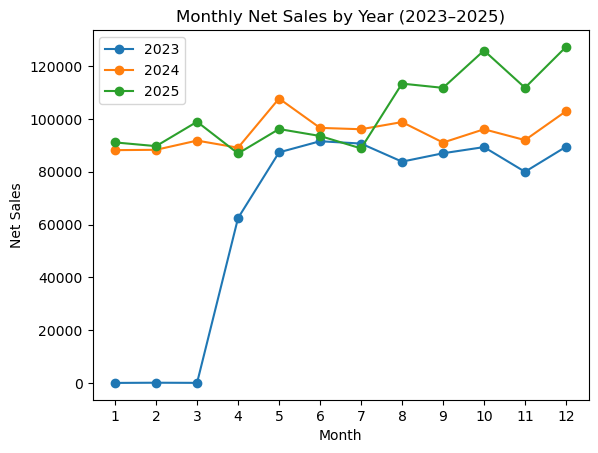

In [28]:
plt.figure()

for year in net_sales_m["year"].unique():
    subset = net_sales_m[net_sales_m["year"] == year]
    plt.plot(subset["month"], subset["net_sales"], marker="o", label=str(year))

plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Net Sales")
plt.title("Monthly Net Sales by Year (2023–2025)")
plt.legend()

plt.show()

## 5.2 Executive Observations — Structural Growth vs Seasonality

- 2025 shows clear structural lift above both 2024 and 2023.
- Seasonal shape appears consistent across years (spring build → late summer strength → Q4 acceleration).
- Peak months cluster around:
  - August–October
  - December
- January–March are historically weakest months.
- 2023 early months show near-zero values (likely partial year or opening ramp).
- 2025 demonstrates both:
  - Higher peaks
  - Higher baseline floor
- This suggests structural business growth, not just cyclicality.

## 6.1 Yearly Revenue Comparison

- Aggregate annual net sales totals.
- Quantify year-over-year structural growth.

In [29]:
annual_totals = (
    net_sales_m
    .groupby("year")["net_sales"]
    .sum()
    .reset_index()
)

annual_totals

,year,net_sales
0,2023,761713.58
1,2024,1138699.57
2,2025,1235400.58


## 6.2 Year-over-Year Growth Rate

- Compute YoY growth percentages.
- Separate structural growth from seasonal fluctuation.

In [30]:
annual_totals["yoy_growth_pct"] = (
    annual_totals["net_sales"]
    .pct_change() * 100
)

annual_totals

,year,net_sales,yoy_growth_pct
0,2023,761713.58,NaN
1,2024,1138699.57,49.491830
2,2025,1235400.58,8.492232


## 7.1 Create Year-Month Pivot Table

- Reshape monthly data for year-over-year comparison.
- Index by month (1–12).
- Columns represent year.
- Values represent monthly net sales.

In [31]:
monthly_pivot = net_sales_m.pivot_table(
    index="month",
    columns="year",
    values="net_sales"
)

monthly_pivot

year,2023,2024,2025
month,,,
1,0.00,88179.74,91107.93
2,77.51,88307.93,89697.50
3,22.99,91799.66,98935.26
4,62450.44,89101.68,86921.38
5,87340.22,107733.46,96177.26
6,91554.85,96614.05,93545.76
7,90673.99,96099.64,88834.20
8,83823.18,98813.95,113381.65
9,86999.69,91057.64,111776.91


## 7.2 Compute Monthly YoY Growth (2024 vs 2023, 2025 vs 2024)

- Calculate month-level growth rates.
- Identify whether growth is broad-based or concentrated.

In [32]:
monthly_pivot["2024_vs_2023_pct"] = (
    (monthly_pivot[2024] - monthly_pivot[2023]) 
    / monthly_pivot[2023] * 100
)

monthly_pivot["2025_vs_2024_pct"] = (
    (monthly_pivot[2025] - monthly_pivot[2024]) 
    / monthly_pivot[2024] * 100
)

monthly_pivot

year,2023,2024,2025,2024_vs_2023_pct,2025_vs_2024_pct
month,,,,,
1,0.00,88179.74,91107.93,inf,3.320706
2,77.51,88307.93,89697.50,1.138310e+05,1.573551
3,22.99,91799.66,98935.26,3.992026e+05,7.773014
4,62450.44,89101.68,86921.38,4.267582e+01,-2.446980
5,87340.22,107733.46,96177.26,2.334920e+01,-10.726658
6,91554.85,96614.05,93545.76,5.525868e+00,-3.175822
7,90673.99,96099.64,88834.20,5.983689e+00,-7.560320
8,83823.18,98813.95,113381.65,1.788380e+01,14.742554
9,86999.69,91057.64,111776.91,4.664327e+00,22.754016


## 7.3 Clean Monthly YoY Comparison Columns

- Avoid infinite or distorted growth percentages.
- Exclude comparisons where prior year baseline is zero.
- Preserve valid structural comparisons.

In [33]:
monthly_pivot_clean = monthly_pivot.copy()

# Replace division by zero results with NaN
monthly_pivot_clean["2024_vs_2023_pct"] = (
    (monthly_pivot_clean[2024] - monthly_pivot_clean[2023]) 
    / monthly_pivot_clean[2023]
)

monthly_pivot_clean["2025_vs_2024_pct"] = (
    (monthly_pivot_clean[2025] - monthly_pivot_clean[2024]) 
    / monthly_pivot_clean[2024]
)

# Remove infinite values
monthly_pivot_clean.replace([float("inf"), float("-inf")], pd.NA, inplace=True)

# Convert to percentage
monthly_pivot_clean["2024_vs_2023_pct"] *= 100
monthly_pivot_clean["2025_vs_2024_pct"] *= 100

monthly_pivot_clean

year,2023,2024,2025,2024_vs_2023_pct,2025_vs_2024_pct
month,,,,,
1,0.00,88179.74,91107.93,<NA>,3.320706
2,77.51,88307.93,89697.50,113831.015353,1.573551
3,22.99,91799.66,98935.26,399202.566333,7.773014
4,62450.44,89101.68,86921.38,42.675824,-2.446980
5,87340.22,107733.46,96177.26,23.349197,-10.726658
6,91554.85,96614.05,93545.76,5.525868,-3.175822
7,90673.99,96099.64,88834.20,5.983689,-7.560320
8,83823.18,98813.95,113381.65,17.8838,14.742554
9,86999.69,91057.64,111776.91,4.664327,22.754016


## 8.1 Compute Quarterly Net Sales

- Aggregate monthly net sales into quarterly totals.
- Evaluate structural strength by quarter.
- Detect whether 2025 growth is evenly distributed.

In [34]:
net_sales_m["quarter"] = net_sales_m["month"].apply(lambda x: (x - 1) // 3 + 1)

quarterly_totals = (
    net_sales_m
    .groupby(["year", "quarter"])["net_sales"]
    .sum()
    .reset_index()
)

quarterly_totals

,year,quarter,net_sales
0,2023,1,100.50
1,2023,2,241345.51
2,2023,3,261496.86
3,2023,4,258770.71
4,2024,1,268287.33
5,2024,2,293449.19
6,2024,3,285971.23
7,2024,4,290991.82
8,2025,1,279740.69
9,2025,2,276644.40


## 8.2 Pivot Quarterly Comparison (2023–2025)

- Create quarter-by-year comparison table.
- Compute YoY growth at quarterly level.

In [35]:
quarterly_pivot = quarterly_totals.pivot_table(
    index="quarter",
    columns="year",
    values="net_sales"
)

quarterly_pivot["2024_vs_2023_pct"] = (
    (quarterly_pivot[2024] - quarterly_pivot[2023]) 
    / quarterly_pivot[2023] * 100
)

quarterly_pivot["2025_vs_2024_pct"] = (
    (quarterly_pivot[2025] - quarterly_pivot[2024]) 
    / quarterly_pivot[2024] * 100
)

quarterly_pivot

year,2023,2024,2025,2024_vs_2023_pct,2025_vs_2024_pct
quarter,,,,,
1,100.50,268287.33,279740.69,266852.567164,4.269065
2,241345.51,293449.19,276644.40,21.588833,-5.726644
3,261496.86,285971.23,313992.76,9.359336,9.798723
4,258770.71,290991.82,365022.73,12.451606,25.440890


## 8.3 Executive Interpretation — Quarterly Decomposition

- 2025 growth is not evenly distributed across quarters.
- Q2 shows contraction vs 2024 (-5.7%).
- Q3 shows moderate structural lift (+9.8%).
- Q4 shows significant acceleration (+25.4%).
- This indicates:
  - Strong late-year demand concentration.
  - Potential seasonality amplification.
  - Growth driven heavily by Q4 performance.
- 2025 structural growth is partially seasonal, not purely baseline lift.

## 9.1 Compute Quarterly Share of Annual Revenue

- Measure each quarter’s contribution to total annual revenue.
- Normalize quarterly totals into percentages.
- Identify revenue concentration patterns.

In [36]:
quarterly_share = quarterly_totals.copy()

# Compute annual totals again (for clarity)
annual_totals = (
    net_sales_m
    .groupby("year")["net_sales"]
    .sum()
    .reset_index()
)

quarterly_share = quarterly_share.merge(
    annual_totals,
    on="year",
    suffixes=("", "_annual")
)

quarterly_share["quarter_share_pct"] = (
    quarterly_share["net_sales"] 
    / quarterly_share["net_sales_annual"] * 100
)

quarterly_share

,year,quarter,net_sales,net_sales_annual,quarter_share_pct
0,2023,1,100.50,761713.58,0.013194
1,2023,2,241345.51,761713.58,31.684549
2,2023,3,261496.86,761713.58,34.330077
3,2023,4,258770.71,761713.58,33.972180
4,2024,1,268287.33,1138699.57,23.560853
5,2024,2,293449.19,1138699.57,25.770554
6,2024,3,285971.23,1138699.57,25.113844
7,2024,4,290991.82,1138699.57,25.554749
8,2025,1,279740.69,1235400.58,22.643723
9,2025,2,276644.40,1235400.58,22.393093


## 9.2 Pivot Quarterly Revenue Share by Year

- Compare quarter share percentages across years.
- Detect shifts in revenue concentration.

In [37]:
quarter_share_pivot = quarterly_share.pivot_table(
    index="quarter",
    columns="year",
    values="quarter_share_pct"
)

quarter_share_pivot

year,2023,2024,2025
quarter,,,
1,0.013194,23.560853,22.643723
2,31.684549,25.770554,22.393093
3,34.330077,25.113844,25.416271
4,33.972180,25.554749,29.546913


## 9.3 Executive Interpretation — Revenue Concentration Shift

- 2024 revenue distribution was balanced across quarters (~25% each).
- 2025 shows material concentration shift toward Q4 (~29.5%).
- Q2 share declined meaningfully vs 2024.
- This confirms:
  - 2025 growth is back-half weighted.
  - Structural acceleration occurred in late-year months.
  - Seasonality intensity increased in 2025.
- Operational implication:
  - Capacity planning must prioritize Q4 scalability.
  - Inventory and staffing buffers required for late-year demand surge.

## 10.1 Compute Average Monthly Seasonality Profile

- Aggregate monthly net sales across all years.
- Compute average revenue per month.
- Remove structural year-level growth effect.
- Identify core seasonal pattern.

In [38]:
monthly_seasonality = (
    net_sales_m
    .groupby("month")["net_sales"]
    .mean()
    .reset_index()
)

monthly_seasonality

,month,net_sales
0,1,59762.556667
1,2,59360.980000
2,3,63585.970000
3,4,79491.166667
4,5,97083.646667
5,6,93904.886667
6,7,91869.276667
7,8,98672.926667
8,9,96611.413333
9,10,103782.880000


## 10.2 Visualize Average Monthly Seasonality

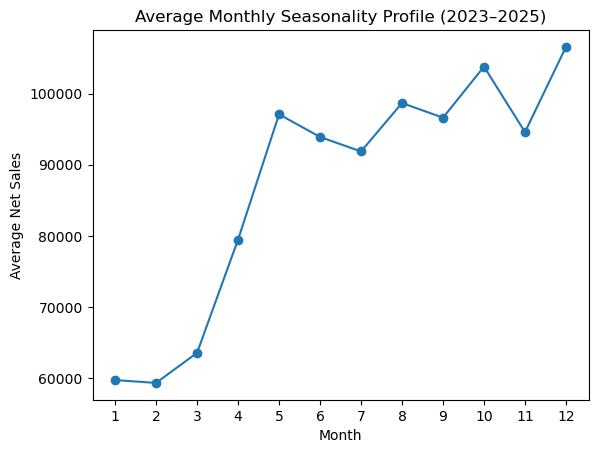

In [39]:
plt.figure()

plt.plot(
    monthly_seasonality["month"],
    monthly_seasonality["net_sales"],
    marker="o"
)

plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Average Net Sales")
plt.title("Average Monthly Seasonality Profile (2023–2025)")

plt.show()

## 10.3 Compute Seasonal Index (Month vs Overall Average)

- Compute overall average monthly revenue.
- Calculate seasonal index for each month.
- Identify months above/below baseline.

In [40]:
overall_monthly_avg = monthly_seasonality["net_sales"].mean()

monthly_seasonality["seasonal_index"] = (
    monthly_seasonality["net_sales"] / overall_monthly_avg
)

monthly_seasonality

,month,net_sales,seasonal_index
0,1,59762.556667,0.686091
1,2,59360.980000,0.681480
2,3,63585.970000,0.729984
3,4,79491.166667,0.912580
4,5,97083.646667,1.114547
5,6,93904.886667,1.078054
6,7,91869.276667,1.054684
7,8,98672.926667,1.132792
8,9,96611.413333,1.109125
9,10,103782.880000,1.191456


## 11.1 Compute Monthly Floor and Peak by Year

- Identify lowest revenue month per year (seasonal floor).
- Identify highest revenue month per year (seasonal peak).
- Evaluate whether growth is peak-driven or baseline-driven.

In [41]:
monthly_extremes = (
    net_sales_m
    .groupby("year")["net_sales"]
    .agg(["min", "max"])
    .reset_index()
)

monthly_extremes

,year,min,max
0,2023,0.00,91554.85
1,2024,88179.74,107733.46
2,2025,86921.38,127282.91


## 11.2 Quantify Floor vs Peak Growth (2024 → 2025)

- Measure absolute change in minimum month.
- Measure absolute change in maximum month.
- Compare relative magnitude of change.

In [42]:
floor_growth = monthly_extremes.loc[2, "min"] - monthly_extremes.loc[1, "min"]
peak_growth = monthly_extremes.loc[2, "max"] - monthly_extremes.loc[1, "max"]

floor_growth, peak_growth

(-1258.3600000000006, 19549.449999999997)

## 12.0 Executive Summary — Multi-Year Trend & Seasonality Analysis

- 2024 represented major structural expansion (+49% YoY).
- 2025 continued growth (+8.5%), but growth pattern shifted.
- 2025 growth was not evenly distributed across quarters.
- Q4 revenue concentration increased materially (≈29.5% of annual revenue).
- Seasonal intensity increased in 2025.
- Floor revenue (weakest month) did not improve materially.
- Peak revenue (strongest month) increased significantly (~$19.5K).
- Conclusion:
  - 2025 growth is peak-driven, not baseline-driven.
  - Operational strategy should prioritize Q4 scalability.
  - Q2 softness warrants targeted demand stabilization strategy.

## 13.1 Annual Revenue Comparison (2023–2025)

- Visualize total annual net sales.
- Highlight structural expansion in 2024.
- Confirm continued growth in 2025.

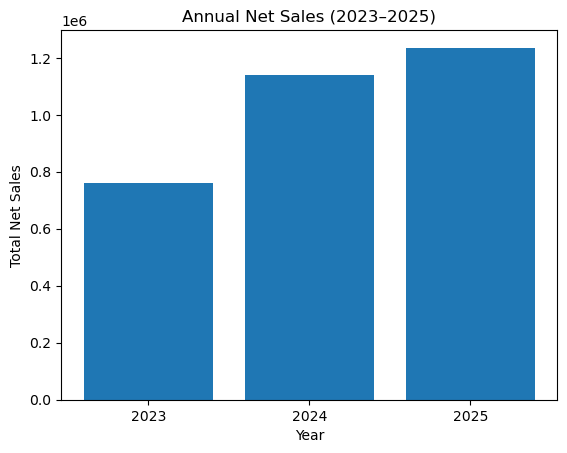

In [43]:
plt.figure()

plt.bar(
    annual_totals["year"].astype(str),
    annual_totals["net_sales"]
)

plt.xlabel("Year")
plt.ylabel("Total Net Sales")
plt.title("Annual Net Sales (2023–2025)")

plt.show()

## 13.2 Quarterly Revenue Distribution — 2025 vs 2024

- Compare quarterly totals for latest two years.
- Visualize Q4 concentration shift.

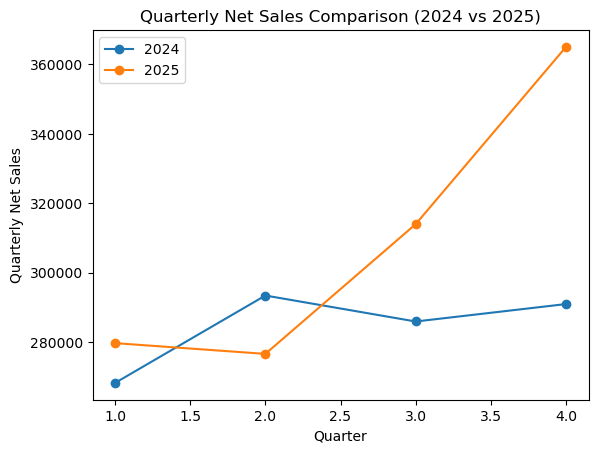

In [44]:
quarterly_compare = quarterly_totals[
    quarterly_totals["year"].isin([2024, 2025])
]

quarterly_pivot_simple = quarterly_compare.pivot_table(
    index="quarter",
    columns="year",
    values="net_sales"
)

plt.figure()

plt.plot(
    quarterly_pivot_simple.index,
    quarterly_pivot_simple[2024],
    marker="o",
    label="2024"
)

plt.plot(
    quarterly_pivot_simple.index,
    quarterly_pivot_simple[2025],
    marker="o",
    label="2025"
)

plt.xlabel("Quarter")
plt.ylabel("Quarterly Net Sales")
plt.title("Quarterly Net Sales Comparison (2024 vs 2025)")
plt.legend()

plt.show()

## 13.3 Seasonal Index Profile

- Display normalized seasonal strength by month.
- Identify structural weak and strong months.

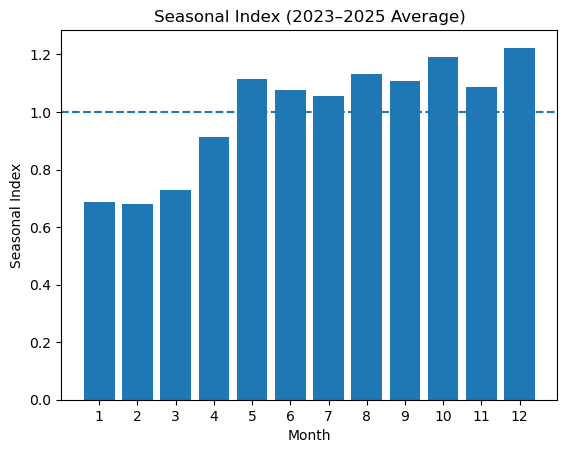

In [45]:
plt.figure()

plt.bar(
    monthly_seasonality["month"],
    monthly_seasonality["seasonal_index"]
)

plt.axhline(1, linestyle="--")

plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Seasonal Index")
plt.title("Seasonal Index (2023–2025 Average)")

plt.show()

## 14.0 Strategic Recommendations — Owner-Level Action Plan

### 1. Q4 Capacity Prioritization

- 2025 growth is peak-driven and heavily concentrated in Q4 (~29.5% of annual revenue).
- Allocate additional staffing capacity in:
  - October
  - November
  - December
- Increase prep buffers and supplier lead-time planning for late-year demand.
- Consider temporary labor or flexible scheduling during Q4 surge window.

---

### 2. Q2 Demand Stabilization Strategy

- Q2 revenue share declined in 2025.
- Develop targeted promotions or catering pushes during:
  - April
  - May
  - Early June
- Explore:
  - Event partnerships
  - Bundle promotions
  - School / graduation demand capture
- Objective: smooth mid-year revenue dip.

---

### 3. Baseline Demand Expansion

- Floor revenue did not materially improve from 2024 to 2025.
- Focus on increasing minimum-month performance (Jan–Mar).
- Strategies may include:
  - Loyalty campaigns
  - Winter-specific promotions
  - Digital marketing spend during slow months
- Goal: raise revenue floor, not just seasonal peaks.

---

### 4. Operational Risk Management

- Peak amplification increases:
  - Labor strain
  - Inventory risk
  - Service bottlenecks
- Integrate findings with:
  - Workbook 4 (Staffing Planning)
  - Workbook 5 (Inventory Planning)
  - Workbook 6 (Capacity Analysis)
- Prioritize system resilience during high-demand windows.

---

### 5. Forward Outlook

- Business shows clear structural strength post-2024 expansion.
- Growth is maturing (8.5% in 2025 vs 49% in 2024).
- Strategic focus should shift from expansion to optimization:
  - Margin control
  - Operational efficiency
  - Demand smoothing

# Workbook 7 — Multi-Year Trend & Seasonality Analysis
## Final Status: Locked

- Multi-year revenue consolidated from raw Clover exports (2023–2025).
- Monthly time-series constructed and validated.
- Structural growth quantified:
  - 2024: +49.5% YoY (expansion year).
  - 2025: +8.5% YoY (normalization + continued growth).
- Quarterly distribution analyzed:
  - 2025 growth concentrated in Q4 (~29.5% of annual revenue).
- Seasonal index constructed:
  - Q1 structurally weakest period.
  - October–December strongest months.
- Floor vs peak analysis:
  - 2025 growth is peak-driven, not baseline-driven.
- Strategic recommendations documented for ownership.

Workbook 7 objective achieved:
- Structural growth separated from cyclicality.
- Seasonality patterns quantified.
- Executive-level operational implications identified.